<a href="https://colab.research.google.com/github/huskeypm/systems_modelling_toolkit/blob/main/interactive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/huskeypm/systems_modelling_toolkit

Cloning into 'systems_modelling_toolkit'...
remote: Enumerating objects: 192, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 192 (delta 87), reused 158 (delta 56), pack-reused 0 (from 0)
Receiving objects: 100% (192/192), 9.56 MiB | 10.71 MiB/s, done.
Resolving deltas: 100% (87/87), done.


In [5]:
import sys
MYPATH="/content/systems_modelling_toolkit/"
sys.path.append('/content/systems_modelling_toolkit/src')


In [4]:
import numpy as np
from parse import parse_interactions, parse_substrates, parse_rates
from network import Network

In [8]:


# 1. Parse your baseline topology

DATAPATH=MYPATH+"/data/pi3k_pten/"
interactions = parse_interactions(DATAPATH + "interactions_expanded.csv")
substrates = parse_substrates(DATAPATH + "substrates_expanded.csv")
rates = parse_rates(DATAPATH + "rates_expanded.csv")

n = Network("custom_run", rates, substrates, interactions)

# 2. Load the fitted parameters (this overwrites the base rates in memory)
n.load_adapter(DATAPATH + "adapter_expanded.json")

# 3. Setup time resolution (e.g., 1000 minutes, 10000 steps)
time = np.linspace(0, 999, num=10000)

# 4. Dial in your custom conditions
# Example: Dosing with 2.0 AU of LPS and 1.5 AU of ATP from t=0 to t=60
n.apply_stimuli(
    stimuli=["LPS", "ATP"],
    amts=[2.0, 1.5],
    time_ranges=[[0, 60], [0, 60]]
)

# 5. Run the ODEs
y = n.y(time, steady_state_fold_normalization=False)

# 6. Save the track and reset for the next condition
n.store_track(y, time, MYPATH+"/outputs/my_custom_run.csv")
n.reset_stimuli()



In [9]:
from plotter import doit

Saved plot to figure.png


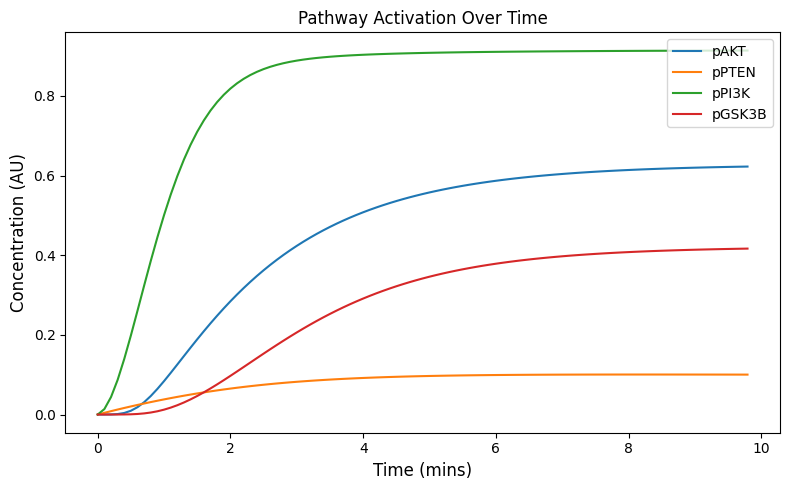

In [12]:
# 1. Load the CSV (overkill)
import pandas as pd
csv_path = MYPATH+"/outputs/ex.csv"  # Change this to your CSV path
df = pd.read_csv(csv_path)
doit(df)